In [1]:
!pip install mlflow

  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
Using cached mlflow-3.14.0-py3-none-any.whl (12.6 MB)
Using cached mlflow_skinny-3.14.0-py3-none-any.whl (3.5 MB)

   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 

In [2]:
import pandas as pd
import numpy as np

import mlflow
import mlflow.sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [3]:
df = pd.read_csv("../data/processed_reviews.csv")

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Sentiment,Clean_Review,Sentiment_Label
0,Lisa,/users/63c2d28aff751c001470ce46,US,1 review,2023-01-14T18:41:59.000Z,1,What happened to quality customer service?,"I ordered several items on Jan 2, this review ...","January 14, 2023",Negative,ordered several item jan review reference retu...,0
1,J Ellery,/users/4f5291a30000640001153f96,GB,6 reviews,2012-03-03T21:50:56.000Z,5,Best on the web,Never any problems.goods always arrive when st...,"March 03, 2012",Positive,never problemsgoods always arrive stated exell...,2
2,Heather Weber,/users/5d37078e6614abe3ab453adf,US,1 review,2019-07-23T13:12:41.000Z,3,Issues with online purchases,"Recently, I have been having issues with my or...","July 23, 2019",Neutral,recently issue order receiving item order rece...,1
3,Mrs Lowe,/users/5666ab6d0000ff0001f14958,GB,2 reviews,2015-12-08T10:07:54.695Z,5,Excellent as always,Very good.,NaN,Positive,good,2
4,Lolo Paz,/users/5d8732fb681610d90db66d2e,US,2 reviews,2019-09-22T08:41:50.000Z,4,Ive been shopping with amazon for…,Ive been shopping with amazon for almost a yea...,"September 22, 2019",Positive,ive shopping amazon almost year get delivery a...,2


In [4]:
X = df["Clean_Review"]

y = df["Sentiment_Label"]

In [5]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
mlflow.set_tracking_uri(
    "sqlite:///mlflow.db"
)

mlflow.set_experiment(
    "Amazon_Sentiment_RandomForest"
)

2026/06/18 07:44:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/18 07:44:39 INFO mlflow.store.db.utils: Updating database tables
2026/06/18 07:44:42 INFO mlflow.tracking.fluent: Experiment with name 'Amazon_Sentiment_RandomForest' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/aksha/OneDrive/InsightCart/notebooks/mlruns/1', creation_time=1781748882007, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781748882007, lifecycle_stage='active', name='Amazon_Sentiment_RandomForest', tags={}, trace_location=None, workspace='default'>

In [8]:
with mlflow.start_run(
    run_name="RF_Model"
):

    rf_model = RandomForestClassifier(
        random_state=42
    )

    rf_model.fit(
        X_train,
        y_train
    )

    y_pred = rf_model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    mlflow.log_param(
        "max_features",
        5000
    )

    mlflow.log_param(
        "random_state",
        42
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "precision",
        precision
    )

    mlflow.log_metric(
        "recall",
        recall
    )

    mlflow.log_metric(
        "f1_score",
        f1
    )

    mlflow.sklearn.log_model(
        rf_model,
        "random_forest_model"
    )

    print("Model Logged Successfully!")

2026/06/18 07:45:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy : 0.9436125409452504
Precision: 0.9478853292058961
Recall   : 0.9436125409452504
F1 Score : 0.9440905133681685
Model Logged Successfully!


In [9]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      2870
           1       1.00      0.92      0.96      2093
           2       0.97      0.92      0.95      3585

    accuracy                           0.94      8548
   macro avg       0.95      0.94      0.95      8548
weighted avg       0.95      0.94      0.94      8548



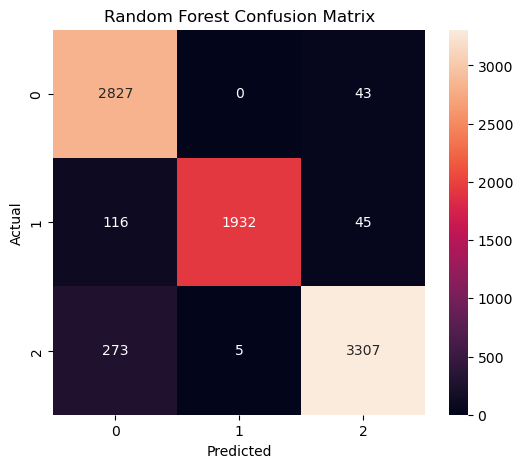

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [13]:
## mlflow ui

In [14]:
import mlflow

print(mlflow.get_tracking_uri())

sqlite:///mlflow.db


In [15]:
import mlflow

print(
    mlflow.get_experiment_by_name(
        "Amazon_Sentiment_RandomForest"
    )
)

<Experiment: artifact_location='file:c:/Users/aksha/OneDrive/InsightCart/notebooks/mlruns/1', creation_time=1781748882007, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781748882007, lifecycle_stage='active', name='Amazon_Sentiment_RandomForest', tags={}, trace_location=None, workspace='default'>


In [17]:
import mlflow

exp = mlflow.get_experiment_by_name(
    "Amazon_Sentiment_RandomForest"
)

print("Experiment ID:", exp.experiment_id)

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id]
)

print(runs)

Experiment ID: 1
                             run_id experiment_id    status  \
0  164edeb729704f488b3dbf69f16a86eb             1  FINISHED   

                                        artifact_uri  \
0  file:c:/Users/aksha/OneDrive/InsightCart/noteb...   

                        start_time                         end_time  \
0 2026-06-18 02:14:46.600000+00:00 2026-06-18 02:15:52.583000+00:00   

   metrics.accuracy  metrics.precision  metrics.f1_score  metrics.recall  \
0          0.943613           0.947885          0.944091        0.943613   

  params.random_state params.max_features tags.mlflow.source.type  \
0                  42                5000                NOTEBOOK   

  tags.mlflow.user tags.mlflow.runName        tags.mlflow.source.name  
0            aksha            RF_Model  08_mlflow_random_forest.ipynb  
